In [49]:
# -------------------------------------------
# 
# generate and save climate input files 
# 
# -------------------------------------------

# Need the following 1d arrays --------------
# 
# [ time ]: decimal year 
# [ temperature ]: degrees C
# [ soil moisture ]: mm / m
# 

# select layers for mean column -------------
# for more info on soil layers, see: https://codes.ecmwf.int/grib/param-db/39 
soilwater_layers = ["volumetric_soil_water_layer_1", "volumetric_soil_water_layer_2"]
soiltemperature_layers = ["soil_temperature_level_1", "soil_temperature_level_2"]
# select the 1d variables
runoff_vars = ["sub_surface_runoff"]

# select time resolutions to output ---------
default_resolution = True   # native time resolution
default_res_name = "hourly" # name for the native time resolution
monthly_mean = True         # average of each month (length = 12 * nyears)
monthly_ltm = True          # climatological average of each month (length = 12)
annual_mean = False         # average of each year (length = nyears)
annual_ltm = True           # climatological annual average (length = 1)

# do we need to convert era5 units ----------
era5_unit_conversions_on = True

# how many times to repeat the selected years in the climate file 
nyears_repeat = 1   # repeat timeseries for all resolutions
                    # (note, longterm mean resolutions are repeated nyears_data * nyears_repeat)
roundtime_to = 5    # number of decimal places to round decimal time (5 works for hourly)

# select start and end time + sites -----------
mintime = '2000-01-01'
maxtime = '2010-12-31'
site_dict = {
    "site_1": {'xlat': 38.148, 'xlon': 360 -121.449, 'name': 'central_valley'},    # central valley
    "site_2": {'xlat': 44.764, 'xlon': 360 -93.202, 'name': 'minneapolis'},     # minneapolis
    "site_3": {'xlat': 33.584, 'xlon': 360 -83.828, 'name': 'atlanta'},     # atlanta
    "site_4": {'xlat': 42.582, 'xlon': 360 -74.029, 'name': 'albany'},     # albany
}

# where to save the data -----------------------
# (note, we'll make a subdir that is `era5_mintime_maxtime`)
savepath = "/home/tykukla/ew-workflows/era5/scepter-ready"

# input file for var details -------------------
inputvar_details_fn = "/home/tykukla/ew-workflows/era5/process/inputvar_details.txt"

# whether to save climate figure ---------------
save_clim_fig = True


In [24]:
# --- read in data
import os 

import icechunk 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.style as mplstyle
import numpy as np
import pandas as pd
import xarray as xr

mplstyle.use('fast')

era5_dir = "era5/preprocessed_icechunk"
era5_bucket = "carbonplan-carbon-removal"

# --- read in icechunk
storage = icechunk.s3_storage(bucket=era5_bucket, prefix=era5_dir, from_env=True)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")
rtds = xr.open_zarr(session.store, consolidated=False)
rtds

<xarray.Dataset> Size: 354GB
Dimensions:                        (time: 184104, latitude: 105, longitude: 241)
Coordinates:
  * latitude                       (latitude) float32 420B 50.0 49.75 ... 24.0
    level                          int64 8B ...
  * longitude                      (longitude) float32 964B 235.0 ... 295.0
  * time                           (time) datetime64[ns] 1MB 2000-01-01 ... 2...
Data variables: (12/19)
    2m_temperature                 (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    evaporation                    (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    land_sea_mask                  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    geopotential                   (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    potential_evaporation          (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    soil_temperature_level_2       (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    ...                             ...
    total_precipitation            (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    soil_type                      (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_2  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_4  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_3  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    surface_runoff                 (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
Attributes:
    last_updated:           2025-07-23 01:54:31.932125+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-17

In [5]:
# --- generate ds of these points 
dslist = []
for site, coords in site_dict.items():
    tmpds = rtds.sel(latitude=coords['xlat'], longitude=coords['xlon'], method='nearest').sel(time=slice(mintime, maxtime))
    tmpds = tmpds.expand_dims(site=[coords['name']]).copy()
    dslist.append(tmpds)

dsx = xr.concat(dslist, dim='site')

In [6]:
def add_decimal_year_coord(
    ds: xr.Dataset,
    native_timecoord_name: str='time'
)->xr.Dataset:
    '''
    Compute decimal year values from datetime coordinate
    and add the values as a new coordinate in the xr
    dataset
    '''
    # --- add time year coordinate
    t0 = ds[native_timecoord_name][0].values  # first time point
    if native_timecoord_name == "year":
        t0 = pd.to_datetime(f"{t0}")
        # convert time to pandas datetime index
        time_dt = pd.to_datetime(dstmp[native_timecoord_name].values, format='%Y')
    else:
        t0 = pd.to_datetime(t0)
        # convert time to pandas datetime index
        time_dt = pd.to_datetime(ds[native_timecoord_name].values)

    # compute elapsed time in fractional years
    years_since_start = (time_dt - t0).total_seconds() / (365.25 * 24 * 3600)
    # round 
    years_since_start = np.round(years_since_start, roundtime_to)

    # update dataset 
    ds = ds.assign_coords(time_years=(native_timecoord_name, years_since_start))

    return ds

In [7]:
# --- pull out just the variables we want 
allvars = [soilwater_layers, soiltemperature_layers, runoff_vars]
allvars_list = sum(allvars, [])
dsvar = dsx[allvars_list].copy()

# get number of years to pass on to repeat the ltm timeseries
dsvar = add_decimal_year_coord(dsvar)
nyears_data = int(np.round(dsvar.time_years.max().values, 0))

In [8]:
# --- unit conversions
if era5_unit_conversions_on:
    # [ era5 soil water ]
    # ... native: m3 m-3
    # ... target: mm m-1 (note, collapsing from 3d to 1d doesn't require any operation)
    mm_per_m = 1000
    dsvar[soilwater_layers] = dsvar[soilwater_layers] * mm_per_m

    # [ era5 temperature ]
    # ... native: K
    # ... target: C
    K_to_C = -273.15
    dsvar[soiltemperature_layers] = dsvar[soiltemperature_layers] + K_to_C

    # [ era5 runoff (or infiltration) ]
    # ... native: m per native time period
    # ... target: mm month-1
    # ( note, we assume 1 month = 30.417 days )
    # get time step duration in months
    alltime = pd.to_datetime(dsvar.time.values)
    dt_days = np.diff(alltime) / np.timedelta64(1, 'D') # time step in days
    dt_months = dt_days / 30.417
    # pad the last value (repeat it) to get the original length
    dt_months = np.append(dt_months, dt_months[-1])
    # convert to data array
    dt_months_da = xr.DataArray(dt_months, coords={'time': dsvar.time}, dims='time')

    # scale runoff to month-1
    for var in runoff_vars: # must loop because we're scaling with a data array
        dsvar[var] = dsvar[var] / dt_months_da


In [9]:
# --- average the climate variables
dsvar['soilwater_mm_meter'] = dsvar[soilwater_layers].to_array(dim='var').mean(dim='var')
dsvar['runoff_mm_month'] = dsvar[runoff_vars].to_array(dim='var').mean(dim='var')
dsvar['temperature_c'] = dsvar[soiltemperature_layers].to_array(dim='var').mean(dim='var')

In [10]:
# --- create datasets for each time resolution 
ds_dict = {}

# [ default resolution ]
if default_resolution:
    ds_dict[default_res_name] = dsvar.copy()

# [ monthly ]
if monthly_mean:
    tmpds_monthly = dsvar.resample(time='1MS').mean()
    # update time_years and save (lost from the mean)
    ds_dict['monthly'] = add_decimal_year_coord(tmpds_monthly)

# [ monthly ltm ]
if monthly_ltm:
    # clim_repeated = xr.DataArray(      # to plot 1-12 over and over for the dsx['time'] period
    #     data=dsvar['time.month'].values,
    #     coords={'time': dsvar['time']},
    #     dims='time'
    # )
    tmpds_monthly_ltm = dsvar.groupby('time.month').mean(dim='time').copy()
    # update time_years (which was lost from the mean)
    time_years_monthly_ltm = (tmpds_monthly_ltm.month.values / 12) - (1/12)  # (time starts at zero)
    tmpds_monthly_ltm = tmpds_monthly_ltm.assign_coords(time_years=('month', time_years_monthly_ltm))  # assign coords
    ds_dict['monthly_ltm'] = tmpds_monthly_ltm

# [ annual ]
if annual_mean:
    tmpds_yearly = dsvar.groupby('time.year').mean(dim='time')
    # update time_years and save (lost from the mean)
    ds_dict['yearly'] = add_decimal_year_coord(tmpds_yearly, native_timecoord_name='year')

# [ annual ltm ]
if annual_ltm:
    ds_dict['yearly_ltm'] = dsvar.groupby('time.year').mean(dim='time').mean(dim='year')

In [11]:
# ---- [ FUNCTION TO WRITE OUTPUT FILE GIVEN ARRAYS ]
def write_output(outdir, var, arrvar, arrtime):
    file_path = os.path.join(outdir, var.filename)
    # open the file in write mode
    with open(file_path, "w") as file:
        # write header
        h1 = "# " + var.colname_time
        h2 = var.colname_var
        file.write(f"{h1}\t{h2}\n")
        # write each pair of values from the arrays to the file
        for value1, value2 in zip(arrtime, arrvar):
            formatted_value1 = f"{value1:.7f}"
            formatted_value2 = f"{value2:.7f}"
            file.write(
                f"{formatted_value1}\t{formatted_value2}\n"
            )  # Separate values by tab and end line with newline character

# ---- [ DEFINE VAR CLASS ]
class Var:
    def __init__(self, varname, filename, dataset_loc, colname_var, colname_time):
        self.varname = varname
        self.filename = filename
        self.dataset_loc = dataset_loc     # not used for era5
        self.colname_var = colname_var
        self.colname_time = colname_time

In [52]:
for site, site_ds in tmpds.groupby('site'):
    print(site)

albany
atlanta
central_valley
minneapolis


In [45]:
# --- define save subdirectory
save_subdir = f'era5_{mintime}_{maxtime}'
savehere = os.path.join(savepath, save_subdir)
if not os.path.exists(savehere):
    os.makedirs(savehere)

# *****************************
# for troubleshoot building ... TEMP
key = "yearly_ltm"
tmpds = ds_dict[key]
thissite = 0
# *****************************


# [ pull out this site ]
tmpds_site = tmpds.isel(site=thissite)
sitename = str(tmpds_site.site.values)
# [ save sub sub dir ]
save_subsubdir = os.path.join(sitename, key)
savehere = os.path.join(savepath, save_subdir, save_subsubdir)
if not os.path.exists(savehere):
    os.makedirs(savehere)

# [ loop through variables ]
with open(inputvar_details_fn) as file:
    # skip the first line
    next(file)
    # loop through each line in the file
    for line in file:
        # create var object
        thisvar = Var(*line.strip().split(","))

        # [ make arrays ]
        if key == "yearly_ltm":
            arrtime = np.array([0])
        else:
            arrtime = tmpds_site.time_years.values
        arrvar = tmpds_site[thisvar.varname].values
        # repeat arrays if `ltm`
        if '_ltm' in key:
            arrtime = np.concatenate([arrtime + i for i in range(nyears_data)])
            arrvar = np.tile(arrvar, nyears_data)

        # [ write output ]
        write_output(savehere, thisvar, arrvar, arrtime)

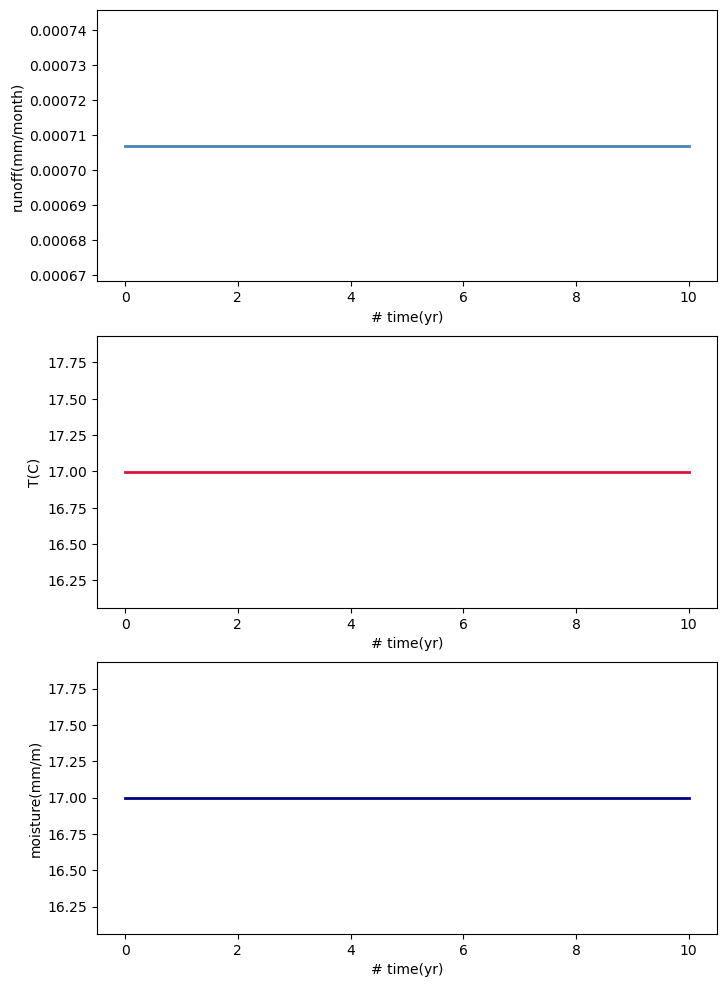

In [50]:

if save_clim_fig:

    # ----------------------
    # plot the results and save in the dir we just created 
    # get file names
    f1, f2, f3 = "q_temp.in", "T_temp.in", "Wet_temp.in"

    # Read the tab-delimited .txt file into a DataFrame
    df1 = pd.read_csv(os.path.join(savehere, f1), delimiter="\t")
    df2 = pd.read_csv(os.path.join(savehere, f2), delimiter="\t")
    df3 = pd.read_csv(os.path.join(savehere, f3), delimiter="\t")

    # --- plot 
    fig = plt.figure(figsize = (8,12))
    gs = gridspec.GridSpec(nrows=3, ncols=1, figure=fig)

    # initialize subplots
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # [ plot 1 ]
    ax1.plot(df1.iloc[:, 0], df1.iloc[:, 1], lw=2, c='steelblue')
    ax1.set_xlabel(df1.columns[0])
    ax1.set_ylabel(df1.columns[1])

    ax2.plot(df2.iloc[:, 0], df2.iloc[:, 1], lw=2, c='crimson')
    ax2.set_xlabel(df2.columns[0])
    ax2.set_ylabel(df2.columns[1])

    ax3.plot(df3.iloc[:, 0], df3.iloc[:, 1], lw=2, c='navy')
    ax3.set_xlabel(df3.columns[0])
    ax3.set_ylabel(df3.columns[1])

    # save figure 
    savename = f'clim-timeseries.png'
    plt.savefig(os.path.join(savehere, savename), dpi=300)